    `

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### **Please read the instructions carefully before starting the project.**
This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned. Read along carefully to complete the project.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. Please replace the blank with the right code snippet. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw an error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* You can the results/observations derived from the analysis here and use them to create your final presentation.


### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
#!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Read the data
df = pd.read_csv("foodhub_order.csv") ## Fill the blank to read the data

In [5]:
# Returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
# Check the shape of the dataset
df.shape## Fill in the blank

(1898, 9)

### Dataset shape: 1,898 rows × 9 columns

### **Question 2:** What are the datatypes of the different columns in the dataset? [0.5 mark]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


what this is saying is that:
- the dataset is a table (DataFrame)
- the dataset contains 1,898 orders
- Rows are indexed from 0 → 1897
- In business terms: FoodHub has 1,898 recorded customer orders
- the dataset has 9 variables (features) describing each order shown below:
Column	               Non-Null Count	  Type	          What it means
 
order_id	            1898	          int64	          Unique order number

customer_id	           1898	           int64	      Customeridentifier

restaurant_name	       1898	           object	       Restaurant name (text)

cuisine_type	        1898	           object	       Cuisine category

cost_of_the_order	    1898	         float64	        Order price ($)

day_of_the_week	        1898	          object	        Weekday or Weekend

rating	                1898	          object	       Customer rating OR “Not given”

food_preparation_time	1898	         int64	            Prep time (minutes)

delivery_time	        1898	         int64	             Delivery time (minutes)

- There are no missing values in the dataset.  This is very important because we do not need to imputation/cleaning.
- Numeric columns (usable for math)

order_id

customer_id

cost_of_the_order

food_preparation_time

delivery_time

Categorical/text columns

restaurant_name

cuisine_type

day_of_the_week

rating 

Important insight: rating is stored as text because it contains "Not given"

- memory usage: 133.6+ KB

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method.  [1 Mark]

In [8]:
# Checking for missing values in the data
df.isna().sum()  #Write the appropriate function to print the sum of null values for each column

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

### Missing values: None

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [9]:
# Get the summary statistics of the numerical data
df.describe().T  # (numerical summary)


,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


In [10]:
df["food_preparation_time"].agg(["min", "mean", "max"]) ## Write the appropriate function to print the statitical summary of the data

min     20.00000
mean    27.37197
max     35.00000
Name: food_preparation_time, dtype: float64

The minimum food preparation time is 20 minutes, the average preparation time is approximately 27.37 minutes, and the maximum preparation time is 35 minutes. This indicates that most orders are prepared within a relatively narrow time range, suggesting consistent kitchen operations across restaurants.

### **Question 5:** How many orders are not rated? [1 mark]

In [11]:
df["rating"].value_counts()  # includes "Not given"

not_rated_count = (df["rating"] == "Not given").sum()
not_rated_count 

np.int64(736)

In [12]:
total_count==1898
(not_rated_count/total_count)*100

NameError: name 'total_count' is not defined

#### Here this means that the total number of orders is 1898 and total orders not rated is 736 which is 38.8% of all orders. This indicates that a significant proportion of customers are not providing feedback, which can limit the company’s ability to assess customer satisfaction accurately.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

#### Order ID

In [14]:
# check unique order ID
df['order_id'].nunique()

1898

#### There are 1898 unique order IDs. This confirms that each row represents a unique order. No duplicate orders were detected in the data.

#### Customer ID

In [15]:
# check unique customer ID
df["customer_id"].nunique()

1200

#### There are 1200 unique customers and 1898 orders. So some customers are  have placed multiple orders.  The Average orders per customer place are 1898/1200 = ~1.58 orders or 1.6 orders. However, this is a low repeat rate and this suggests that customer retention stratigies could further improve from long term engagement. 

#### Restaurant name

In [16]:
# check unique Restaurant Name
df["restaurant_name"].nunique() ## Complete the code to find out number of unique Restaurant Name

178

This tells us that there are 178 unique resturaunts.  The market is fragmented.  A few resturaunts may drive a large portion of the revenue.

#### Cuisine type

In [18]:
# Check unique cuisine type
df["cuisine_type"].nunique() ## Complete the code to find out  number of  unique cuisine type

14

There are also 14 cousine categories where American couisne is dominante with the highest count followed by Japenese and Italian Cuisines.  Other cuisines such as Korean, Veitnamese, Southern, Thai, etc. have a lower demand presense. Overall, FoodHub demand is concentrated in a few coisines.

<Axes: xlabel='cuisine_type', ylabel='count'>

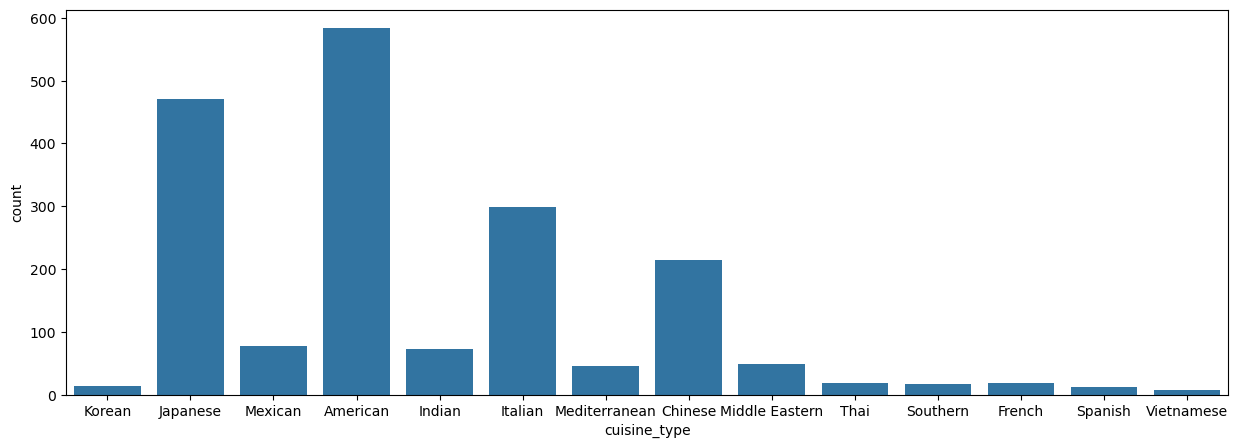

In [22]:
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'cuisine_type') ## Create a countplot for cuisine type.

#### Cost of the order

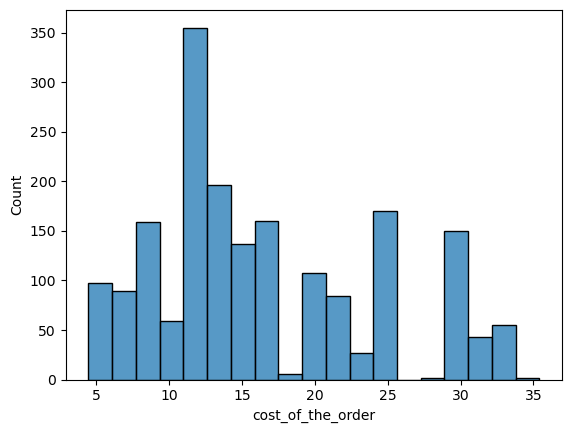

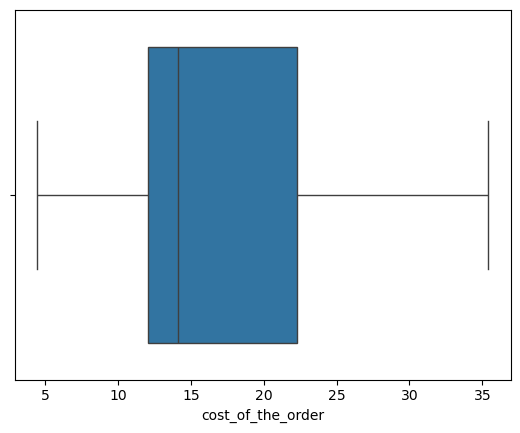

In [23]:
sns.histplot(data=df,x='cost_of_the_order') ## Histogram for the cost of order
plt.show()
sns.boxplot(data=df,x='cost_of_the_order') ## Boxplot for the cost of order
plt.show()

An observation here is that an order cost range is from 5 dollars to 35 dollars  and most orders fall between $10 and $20. The distribution is slightly skewed to the right.  Some higher cost orders or outliers are close to 30 dollars - 35 dollars .

#### Day of the week

In [8]:
# # Check the unique values
df['day_of_the_week'].unique() ## Complete the code to check unique values for the 'day_of_the_week' column

array(['Weekend', 'Weekday'], dtype=object)

<Axes: xlabel='day_of_the_week', ylabel='count'>

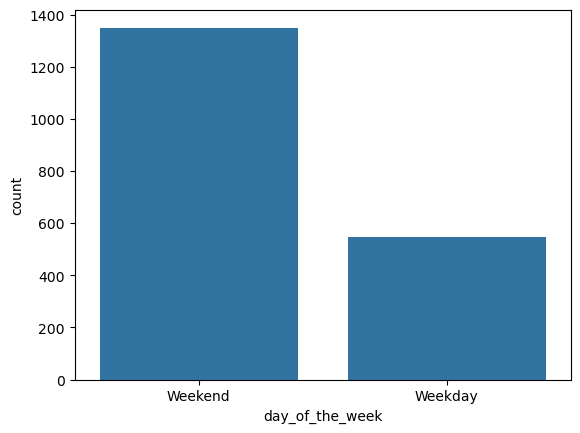

In [19]:
sns.countplot(data = df, x = 'day_of_the_week') ## Complete the code to plot a bar graph for 'day_of_the_week' column

In [21]:
weekend_count = df[df['day_of_the_week'] == 'Weekend'].shape[0]
weekday_count = df[df['day_of_the_week'] == 'Weekday'].shape[0]

print("Weekend orders:", weekend_count)
print("Weekday orders:", weekday_count)

Weekend orders: 1351
Weekday orders: 547


What this is saying is that  (1351/1898)*100 =71% occur on weekends and (547/1898)*100 =29% occurs on weekdays.  Weekend demand is 1351/547 =2.4 times higher than weekday deman.  This is a big difference in the number of orders received during the weekends and weekdays. This maybe due to customer behavior such as social gatherings (e.g. soccer games, birthday parties, work events), wanting to spend more time with familiy and less time cooking, etc. The operational impact to this is that Resturaunts will need to make sure to have enough staff on the weekends to handle increased worklowd, targeted market campaigns should happen mainly on weekends and be balanced on weekdays, restruants should be closed dates should be sometime during the week and not the weekend.  

#### Rating

In [22]:
# Check the unique values
df['rating'].unique()## Complete the code to check unique values for the 'rating' column

array(['Not given', '5', '3', '4'], dtype=object)

<Axes: xlabel='rating', ylabel='count'>

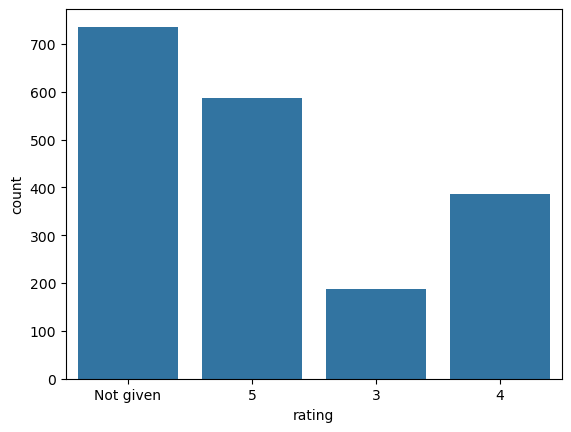

In [24]:
sns.countplot(data = df, x = 'rating') ## Complete the code to plot bar graph for 'rating' column


In [25]:
df['rating'].value_counts()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

In [26]:
df['rating'].value_counts(normalize=True) * 100

rating
Not given    38.777661
5            30.979979
4            20.337197
3             9.905163
Name: proportion, dtype: float64

The rating distribution shows that 736 orders (38.8%) were not rated. Among the 1,162 rated orders, the majority received high ratings, with 588 (31%) rated 5 stars and 386 (20%) rated 4 stars. Only 188 (9.9%) received 3 stars, and no ratings of 1 or 2 were observed. This suggests strong overall customer satisfaction. However, the high percentage of unrated orders presents an opportunity for FoodHub to improve customer feedback participation through incentives or reminders.

#### Food Preparation time

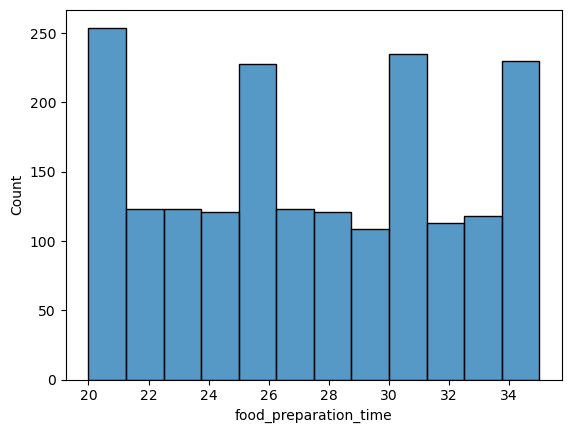

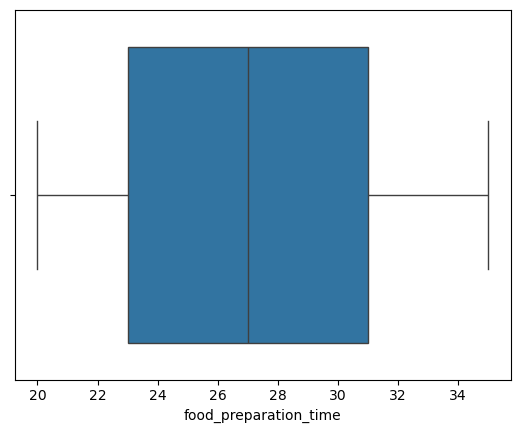

In [30]:
sns.histplot(data=df,x='food_preparation_time') ## Complete the code to plot the histogram for the food preparation time
plt.show()
sns.boxplot(data=df,x='food_preparation_time') ## Complete the code to plot the boxplot for the food preparation time
plt.show()

In [34]:
df['food_preparation_time'].value_counts(normalize=True) * 100

food_preparation_time
21    7.112750
23    6.480506
27    6.480506
22    6.480506
28    6.375132
24    6.375132
20    6.269758
30    6.269758
33    6.217071
35    6.164384
31    6.111697
26    6.059009
25    5.953635
34    5.953635
32    5.953635
29    5.742887
Name: proportion, dtype: float64

The histogram and boxplot show that the minimum food prep time is 20 minutes and the maximum is 35 minutes.  Most values are between 23 and 31 minutes, while the median is around 27 minutes.  The distribution looks fairly symetric with no extreme outliers.  

In [35]:
df['food_preparation_time'].value_counts(normalize=True) * 100

food_preparation_time
21    7.112750
23    6.480506
27    6.480506
22    6.480506
28    6.375132
24    6.375132
20    6.269758
30    6.269758
33    6.217071
35    6.164384
31    6.111697
26    6.059009
25    5.953635
34    5.953635
32    5.953635
29    5.742887
Name: proportion, dtype: float64

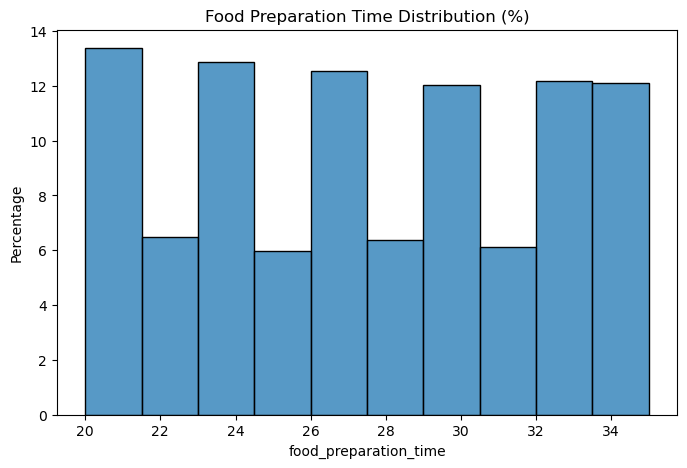

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='food_preparation_time',
    bins=10,
    stat='percent'
)

plt.ylabel("Percentage")
plt.title("Food Preparation Time Distribution (%)")
plt.show()

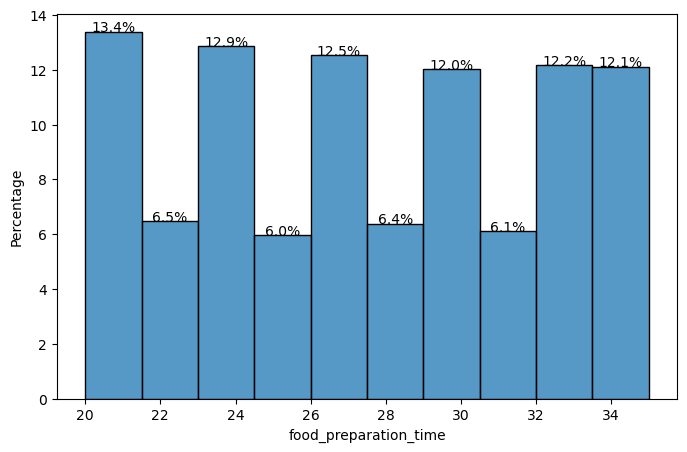

In [38]:
plt.figure(figsize=(8,5))
ax = sns.histplot(
    data=df,
    x='food_preparation_time',
    bins=10,
    stat='percent'
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            f'{height:.1f}%',
            ha='center'
        )

plt.ylabel("Percentage")
plt.show()

From the histogram, the highest percentage occurs around 20-21 minutes (~13.4%) while other times fall between 12%-13% with smaller bins around 6%-6.5%. There aren't any extreme spikes or drops. All prep times fall between 20 and 35 min. This indicates no strong skew, no unusual clustering, and no extreme prep delays. Operationaly this means that the restaruants maintain consistent preparation times. THere is no major bottleneck in food prep.  Additionally, food prep has controlled variability maning the systems is predictable and delivery time may contribute to overall delays. 

#### Delivery time

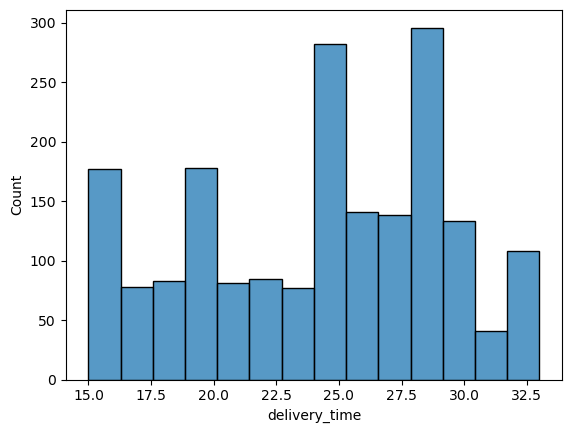

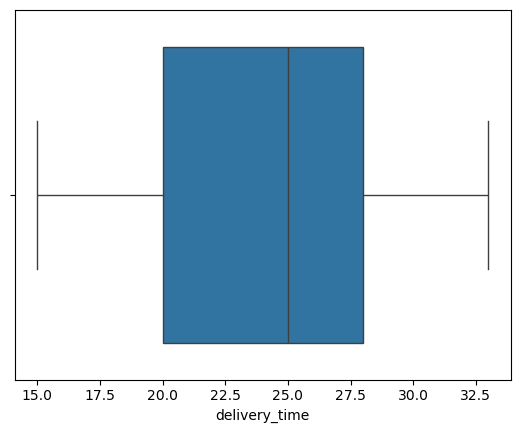

In [39]:
sns.histplot(data=df,x='delivery_time') ## Complete the code to plot the histogram for the delivery time
plt.show()
sns.boxplot(data=df,x='delivery_time') ## Complete the code to plot the boxplot for the delivery time
plt.show()

In [40]:
df['delivery_time'].value_counts(normalize=True) * 100

delivery_time
24    8.535300
28    7.797682
29    7.797682
26    7.428872
27    7.270811
30    7.007376
25    6.322445
19    4.741834
16    4.741834
20    4.636459
15    4.583772
22    4.478398
18    4.373024
21    4.267650
17    4.109589
23    4.056902
32    3.108535
33    2.581665
31    2.160169
Name: proportion, dtype: float64

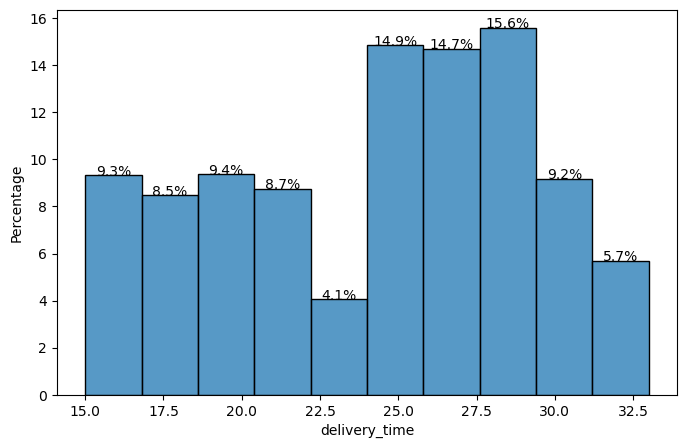

In [41]:
plt.figure(figsize=(8,5))
ax = sns.histplot(
    data=df,
    x='delivery_time',
    bins=10,
    stat='percent'
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height,
            f'{height:.1f}%',
            ha='center'
        )

plt.ylabel("Percentage")
plt.show()

Delivery time is moderately centered around 25-29 minutes.  ther eis a slight skew to the right where we see some deliveries 31-33 minutes.  Delivery time looks like it has more variability than prep time.  Compared to food prep time, delivery time spreads more across bins, shows slightly more dispersion, and likely influenced by certain factors such as traffic, distance, or driver availabilty.  

### **Question 7:** Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [47]:
# Get top 5 restaurants with highest number of orders
top5_restaurants=df['restaurant_name'].value_counts().head(5) ## Complete the code
top5_restaurants

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

In [48]:
top5_percent = (top5_restaurants / len(df)) * 100
top5_percent

restaurant_name
Shake Shack                  11.538462
The Meatball Shop             6.954689
Blue Ribbon Sushi             6.269758
Blue Ribbon Fried Chicken     5.057956
Parm                          3.582719
Name: count, dtype: float64

The top 5 restaurants by number of orders are Shake Shack (219 or 11.5%), The Meatball Shop (132 or 6.95%), Blue Ribbon Sushi (119 or 6.27%), Blue Ribbon Fried Chicken (96 or 5.06%), and Parm (68 or 3.58%). Shake Shack leads significantly, accounting for approximately 11.5% of total orders. The distribution shows that demand is concentrated among a few high-performing restaurants. FoodHub may benefit from strengthening partnerships and promotional efforts with these top restaurants to maximize revenue and customer engagement.The top 5 restaurants contribute approximately one-third (~33–35%)of total orders, indicating that demand is concentrated among a small subset of restaurants. Shake Shack alone accounts for over 11% of total orders, highlighting its strong popularity among customers.

### **Question 8:** Which is the most popular cuisine on weekends? [1 mark]

In [50]:
# Get most popular cuisine on weekends
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['cuisine_type'].value_counts() ## Complete the code to check unique values for the cuisine type on weekend

cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Mediterranean      32
Middle Eastern     32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64

In [52]:
df_weekend['cuisine_type'].value_counts(normalize=True) * 100

cuisine_type
American          30.717987
Japanese          24.796447
Italian           15.321984
Chinese           12.065137
Mexican            3.923020
Indian             3.626943
Mediterranean      2.368616
Middle Eastern     2.368616
Thai               1.110289
French             0.962250
Korean             0.814212
Southern           0.814212
Spanish            0.814212
Vietnamese         0.296077
Name: proportion, dtype: float64

American cuisine is the most popular cuisine on weekends, accounting for 30.7% of weekend orders. Japanese cuisine follows closely at 24.8%. Together, these two cuisines account for over 55% of weekend demand. Additionally, the top four cuisines (American, Japanese, Italian, and Chinese) make up approximately 83% of total weekend orders, indicating strong demand concentration in a limited number of cuisine categories. FoodHub can leverage this insight by prioritizing promotions and partnerships within these high-demand cuisine segments during weekends.

### **Question 9:** What percentage of the orders cost more than 20 dollars? [2 marks]


In [54]:
# Get orders that cost above 20 dollars
df_greater_than_20 = df[df['cost_of_the_order'] > 20]

# Calculate the number of total orders where the cost is above 20 dollars
print('The number of total orders that cost above 20 dollars is:', df_greater_than_20.shape[0])

# Calculate percentage of such orders in the dataset
percentage = (df_greater_than_20.shape[0] / df.shape[0]) * 100

print("Percentage of orders above 20 dollars:", round(percentage, 2), '%')

The number of total orders that cost above 20 dollars is: 555
Percentage of orders above 20 dollars: 29.24 %


Out of 1,898 total orders, 555 orders (29.24%) cost more than 20 dollars. Which indicates that nearly one-third of customers place higher-value orders. While the majority of orders are priced at 20 dollars or below, the higher-priced segment represents a significant revenue opportunity, especially since the company earns a higher commission on orders above 20 dollars. Targeted promotions on premium meals could further increase overall profitability.

### **Question 10:** What is the mean order delivery time? [1 mark]

In [55]:
# Get the mean delivery time
mean_del_time = df['delivery_time'].mean()  ## Write the appropriate function to obtain the mean delivery time

print('The mean delivery time for this dataset is', round(mean_del_time, 2), 'minutes')

The mean delivery time for this dataset is 24.16 minutes


The mean delivery time is 24.26 minutes, inticating that most deliveries are completed within approximately 25 minutes after pickup. When combined with the average food preparation time, customers receive their orders in roughly 50 minutes from placement. This suggests relatively efficient delivery operations; however, further optimization of delivery logistics could help reduce total service time and improve customer satisfaction.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [56]:
# Get the counts of  each customer_id
df['customer_id'].value_counts().head(3)  ## Write the appropriate column name to get the top 5 cmost frequent customers

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

The top frequent customers are customer IDs 52832 (13 orders), 47440 (10 orders), and 83287 (9 orders). These customers exhibit significantly higher ordering frequency compared to the average of approximately 1.6 orders per customer. This indicates the presence of a loyal customer segment. Offering promotional discounts, loyalty rewards, or exclusive offers to these high-frequency customers could further strengthen retention and increase lifetime value.

### Multivariate Analysis

### **Question 12:** Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]

#### Cuisine vs Cost of the order

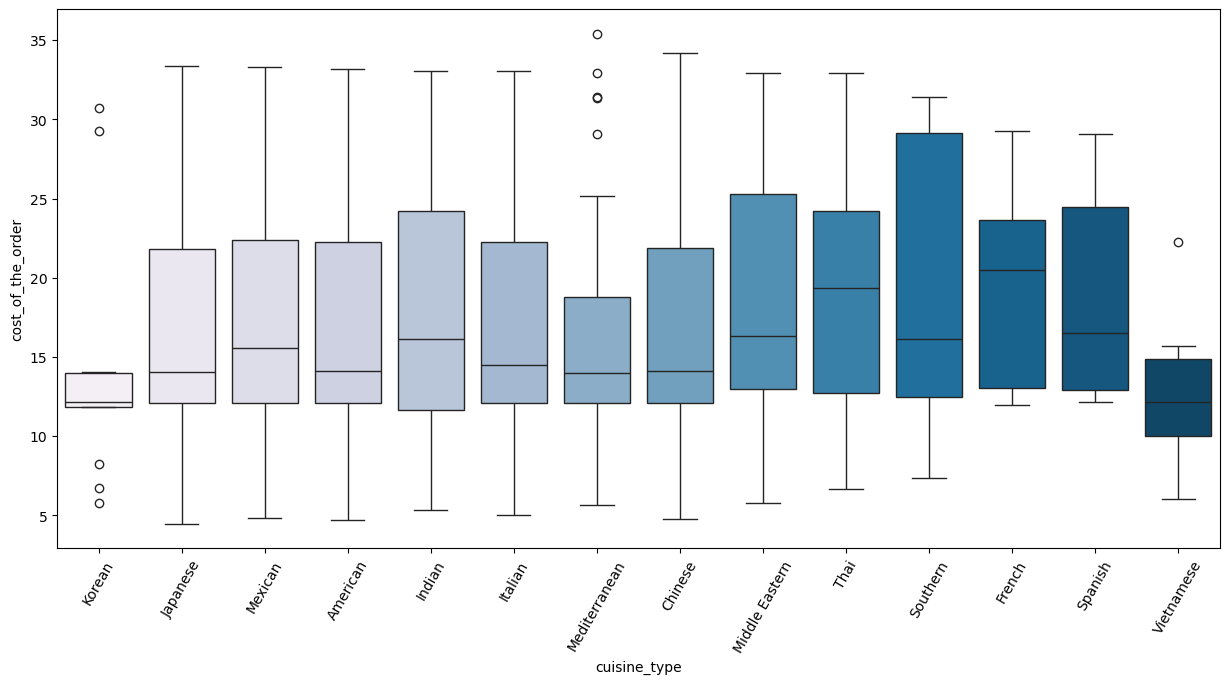

In [57]:
# Relationship between cost of the order and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu', hue = "cuisine_type")
plt.xticks(rotation = 60)
plt.show()

The boxplot reveals clear variation in order cost across cuisine types. French cuisine exhibits one of the highest median costs, followed by Southern and Thai cuisines, suggesting a premium pricing structure. American, Japanese, Italian, and Mexican cuisines fall within a moderate price range, indicating strong mid-market positioning. Vietnamese cuisine shows a comparatively lower median cost. The presence of outliers and varying interquartile ranges indicates price diversity within cuisines. These differences suggest that cuisine type plays a significant role in pricing strategy and revenue generation, with certain cuisines likely contributing higher per-order revenue.

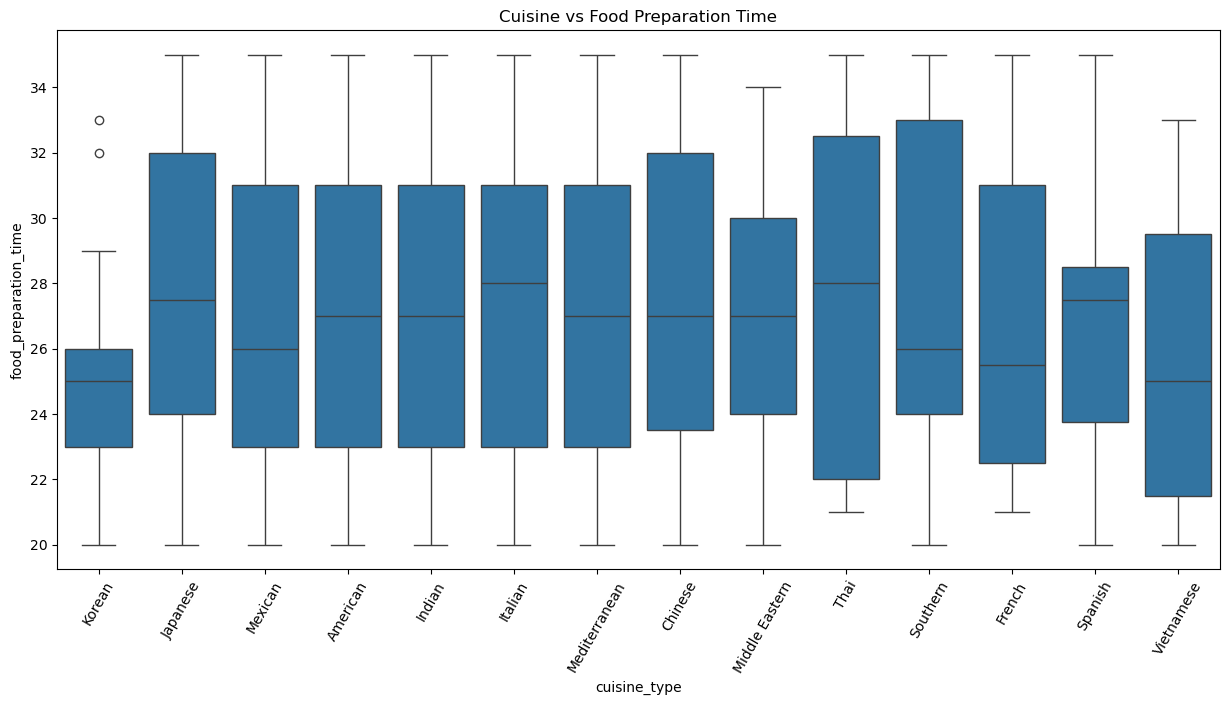

In [58]:
# Relationship between food preparation time and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x='cuisine_type',
            y='food_preparation_time',
            data=df)
  ## Complete the code to visualize the relationship between food preparation time and cuisine type using boxplot
plt.xticks(rotation = 60)
plt.title("Cuisine vs Food Preparation Time")
plt.show()

The food preparation time is relatively consistent across cuisine types, with most median values ranging between 25 and 28 minutes. Italian and Thai cuisines show slightly higher preparation times, while Vietnamese and Korean cuisines appear slightly faster. Overall, variability is limited, indicating standardized kitchen operations across restaurants. Cuisine type does not appear to significantly impact preparation time.

#### Cuisine vs Food Preparation time

#### Day of the Week vs Delivery time

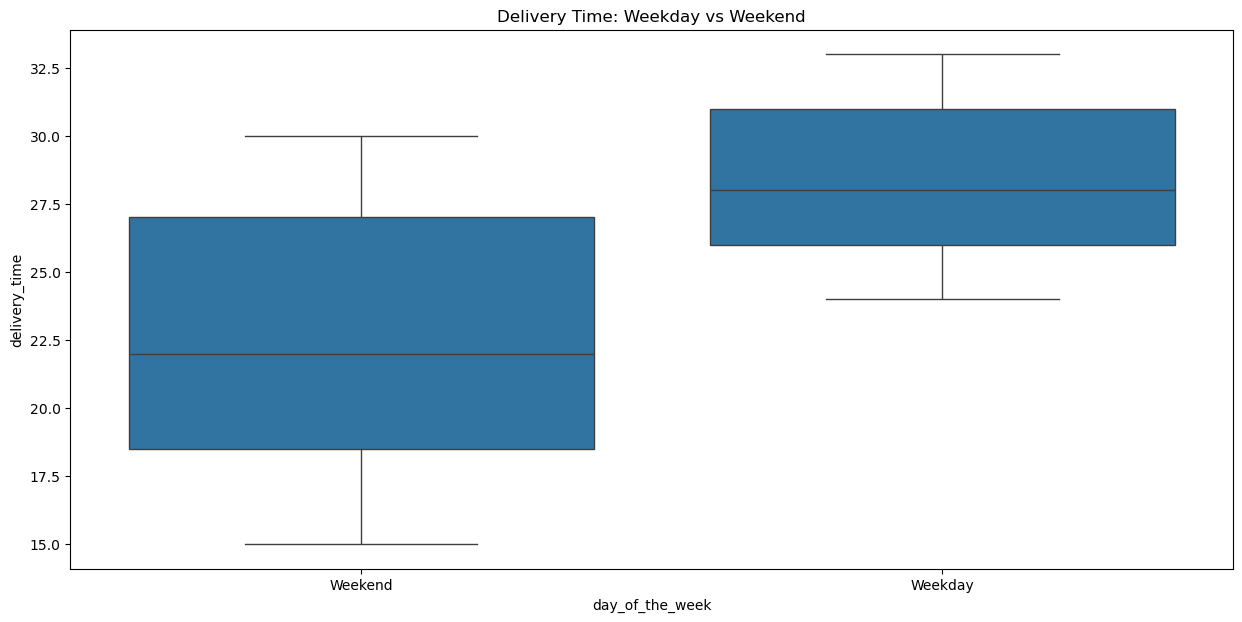

In [59]:
# Relationship between day of the week and delivery time
plt.figure(figsize=(15,7))
sns.boxplot(x='day_of_the_week',
            y='delivery_time',
            data=df)  ## Complete the code to visualize the relationship between day of the week and delivery time using boxplot
plt.title("Delivery Time: Weekday vs Weekend")
plt.show()

The boxplot shows that median delivery time is higher on weekdays (28 minutes) compared to weekends (22 minutes). This suggests that weekday deliveries may be affected by higher traffic congestion or operational demand. FoodHub may consider increasing delivery resources during weekdays to improve efficiency and reduce delays.

#### Run the below code and write your observations on the revenue generated by the restaurants.

In [61]:
df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(14)

restaurant_name
Shake Shack                      3579.53
The Meatball Shop                2145.21
Blue Ribbon Sushi                1903.95
Blue Ribbon Fried Chicken        1662.29
Parm                             1112.76
RedFarm Broadway                  965.13
RedFarm Hudson                    921.21
TAO                               834.50
Han Dynasty                       755.29
Blue Ribbon Sushi Bar & Grill     666.62
Rubirosa                          660.45
Sushi of Gari 46                  640.87
Nobu Next Door                    623.67
Five Guys Burgers and Fries       506.47
Name: cost_of_the_order, dtype: float64

Revenue analysis shows that Shake Shack generates the highest total revenue (3579.53 dollars), significantly outperforming other restaurants. The Meatball Shop and Blue Ribbon Sushi follow with 2145.21 dollars and 1903.95 dollars respectively. The revenue distribution indicates strong concentration among a few high-performing restaurants, suggesting that a small subset of restaurants drives a large portion of total platform revenue. Strengthening partnerships and promotional visibility for these restaurants could further enhance overall profitability.

#### Rating vs Delivery time

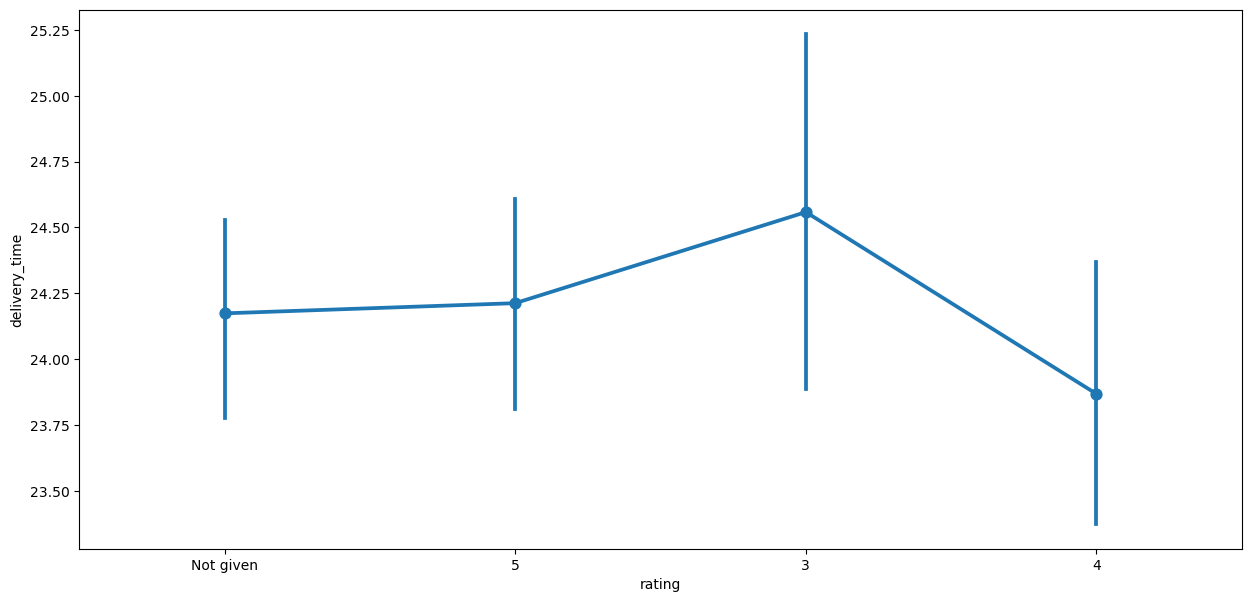

In [60]:
# Relationship between rating and delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'delivery_time', data = df)
plt.show()

The relationship between rating and delivery time shows only minor variation across rating levels. Although slightly higher delivery times are observed for lower ratings, the overall differences are small. This suggests that delivery time alone may not be the primary driver of customer satisfaction, and other factors such as food quality and service experience likely play a more significant role.

#### Rating vs Food preparation time

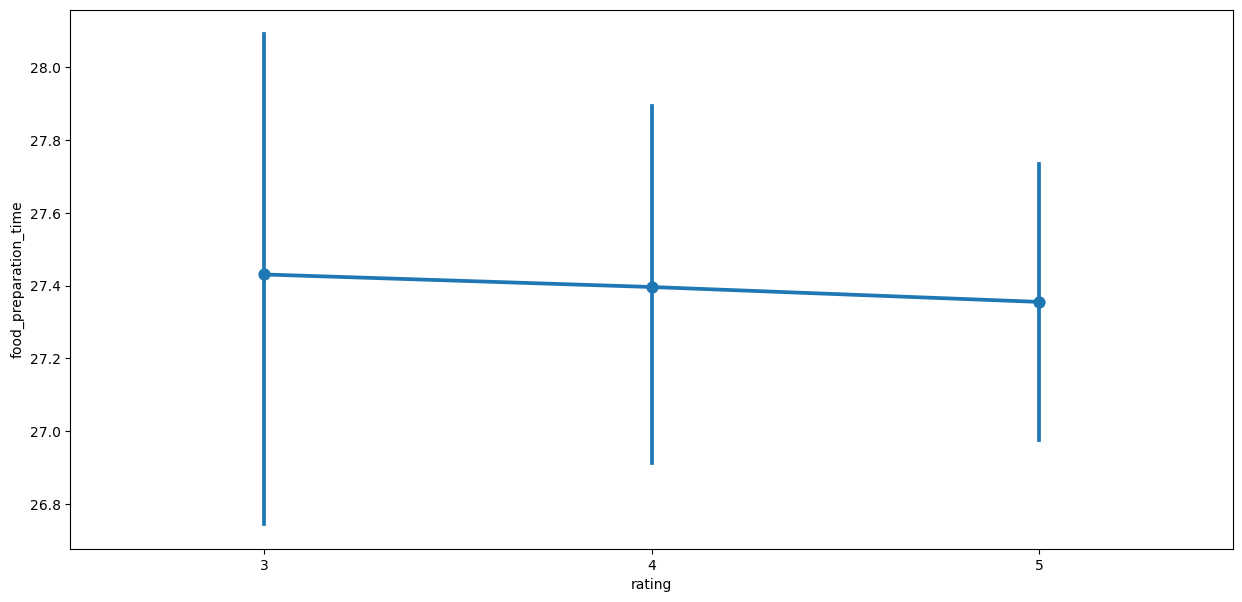

In [67]:
# Relationship between rating and food preparation time
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating',
              y='food_preparation_time',
              data=df_rated) ## Complete the code to visualize the relationship between rating and food preparation time using pointplot
plt.show()

The relationship between rating and food preparation time shows minimal variation across rating levels. The average preparation time remains approximately 27 minutes for ratings 3, 4, and 5, with overlapping confidence intervals. This indicates that preparation time does not significantly influence customer ratings. Other factors such as food quality, delivery experience, and order accuracy may play a more important role in determining customer satisfaction.

#### Rating vs Cost of the order

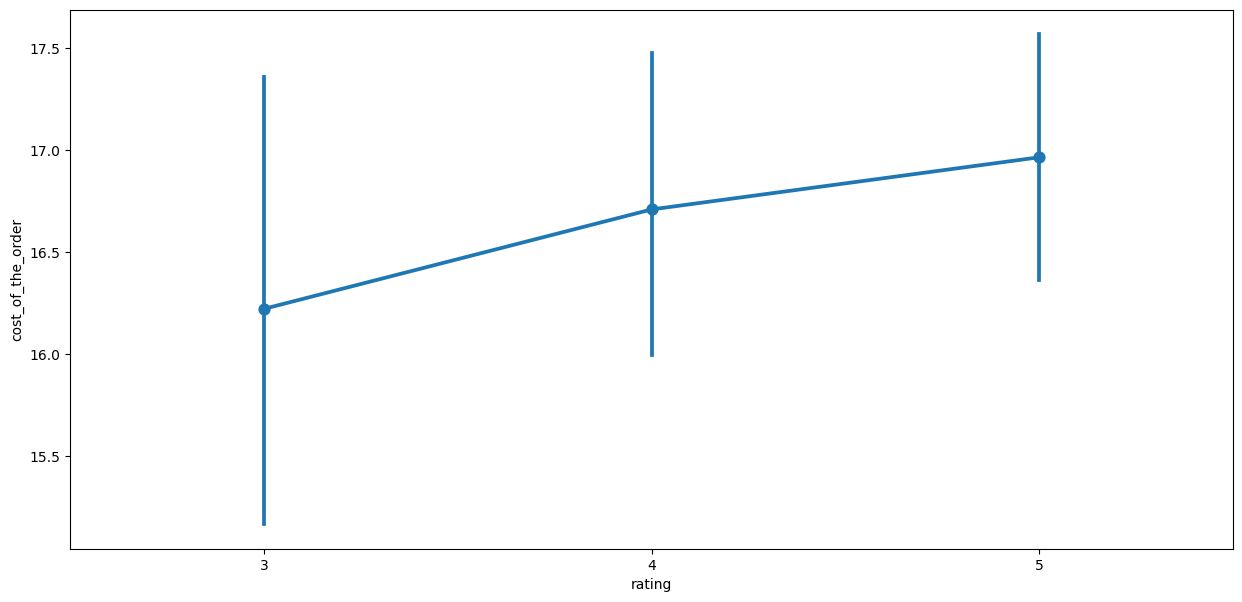

In [68]:
# Relationship between rating and cost of the order
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating',
              y='cost_of_the_order',
              data=df_rated) ## Complete the code to visualize the relationship between rating and cost of the order using pointplot
plt.show()

The relationship between rating and cost of the order shows a slight positive trend. Orders with higher ratings tend to have marginally higher average costs, with rating 5 orders averaging approximately 17 dollars compared to 16.2 dollars for rating 3. This suggests that higher-priced meals may be associated with slightly better customer satisfaction, possibly reflecting perceived food quality or restaurant reputation. However, the difference is modest, indicating that cost alone does not strongly determine ratings.

#### Correlation among variables

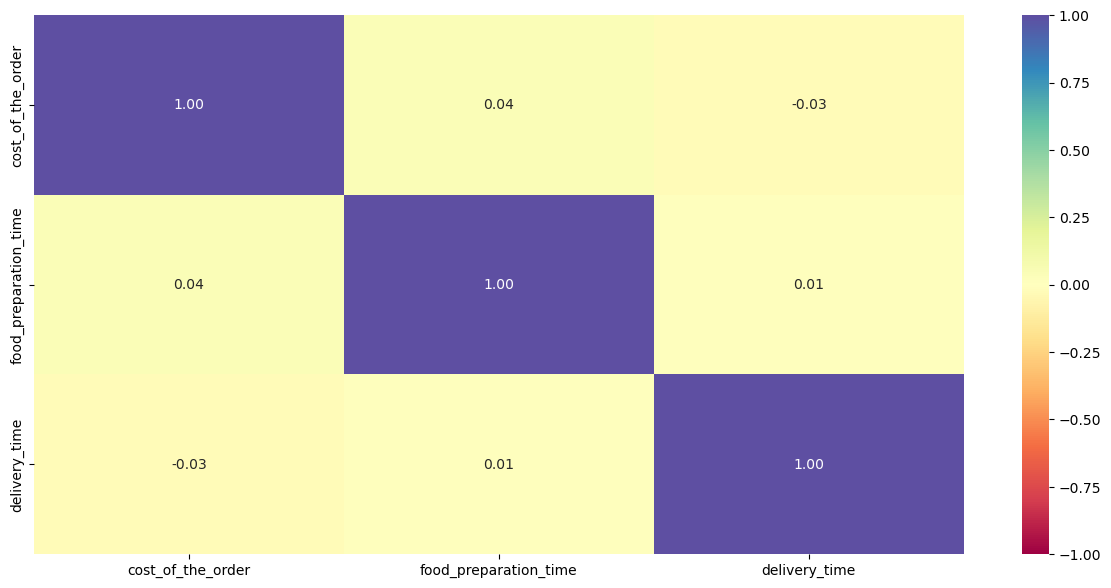

In [62]:
# Plot the heatmap
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

The correlation analysis reveals very weak relationships among cost, food preparation time, and delivery time. The correlation between cost and preparation time (0.04) and between preparation and delivery time (0.01) are close to zero, indicating minimal linear association. Similarly, the correlation between cost and delivery time (-0.03) is negligible. These findings suggest that pricing, preparation time, and delivery time operate largely independently, and no strong linear relationships exist among these operational variables.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [69]:
# Filter the rated restaurants
df_rated = df[df['rating'] != 'Not given'].copy()

# Convert rating column from object to integer
df_rated['rating'] = df_rated['rating'].astype('int')

# Create a dataframe that contains the restaurant names with their rating counts
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()
df_rating_count.head()

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41


Shake Shack has the highest number of ratings (133), followed by The Meatball Shop (84), Blue Ribbon Sushi (73), and Blue Ribbon Fried Chicken (64). These restaurants exceed the minimum rating count threshold of 50. After applying the second condition of average rating greater than 4, four restaurants qualify for the promotional offer.

In [72]:
# Get the restaurant names that have rating count more than 50
rest_names = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name'] ## Complete the code to get the restaurant names having rating count more than 50

# Filter to get the data of restaurants that have rating count more than 50
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()

# Group the restaurant names with their ratings and find the mean rating of each restaurant
df_mean_4_rating = df_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index().dropna() ## Complete the code to find the mean rating

# filter for average rating greater than 4
df_avg_rating_greater_than_4 = df_mean_4_rating[df_mean_4_rating['rating'] > 4].sort_values(by='rating', ascending=False).reset_index(drop=True)  ## Complete the code to find restaurants with rating > 4

df_avg_rating_greater_than_4

,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178


Based on the promotional criteria (rating count greater than 50 and average rating above 4), four restaurants qualify: The Meatball Shop (4.51), Blue Ribbon Fried Chicken (4.33), Shake Shack (4.28), and Blue Ribbon Sushi (4.22). These restaurants demonstrate both strong customer engagement and high satisfaction levels. Featuring these restaurants in promotional advertisements is likely to enhance customer trust, drive increased order volume, and maximize platform revenue.

In [ ]:
Based on the promotional criteria (rating count > 50 and average rating > 4), four restaurants qualify: The Meatball Shop (4.51), Blue Ribbon Fried Chicken (4.33), Shake Shack (4.28), and Blue Ribbon Sushi (4.22). These restaurants demonstrate both high customer engagement and strong customer satisfaction. Featuring these restaurants in promotional advertisements is likely to enhance customer trust, drive higher conversions, and maximize revenue potential.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

After applying the commission structure (25% on orders above 20 dollars and 15% on orders above 5 dollars), the total net revenue generated across all orders is approximately 6,166.30 dollars . This indicates that commission-based revenue is strongly influenced by higher-value orders. Since nearly 30% of orders exceed 20 dollars, promoting premium-priced meals could significantly increase overall profitability. On average, the company earns approximately 3.25 per dollarsorder, highlighting the importance of both order volume and order value in revenue generation.

In [73]:
#function to determine the revenue
def compute_rev(x):
    if x > 20:
        return x*0.25
    elif x > 5:
        return x*0.15
    else:
        return x*0

df['Revenue'] = df['cost_of_the_order'].apply(compute_rev) ## Write the apprpriate column name to compute the revenue
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,1.7385


In [74]:
# get the total revenue and print it
total_rev = df['Revenue'].sum() ## Write the appropriate function to get the total revenue
print('The net revenue is around', round(total_rev, 2), 'dollars')

The net revenue is around 6166.3 dollars


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)[2 marks]


Approximately 10.54% of orders take more than 60 minutes from the time the order is placed to delivery. This means that about 1 in 10 customers experience a delivery time exceeding one hour. While the majority of orders (nearly 90%) are delivered within 60 minutes, the remaining delayed segment may negatively impact customer satisfaction. Reducing these longer delivery cases could improve service reliability and enhance overall customer experience.

In [77]:
# Calculate total delivery time and add a new column to the dataframe df to store the total delivery time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']


## Write the code below to find the percentage of orders that have more than 60 minutes of total delivery time (see Question 9 for reference)

# Filter orders with total time > 60 minutes
df_more_than_60 = df[df['total_time'] > 60]

# Calculate percentage
percentage_over_60 = (df_more_than_60.shape[0] / df.shape[0]) * 100

print("Percentage of orders taking more than 60 minutes:",
      round(percentage_over_60, 2), "%")



Percentage of orders taking more than 60 minutes: 10.54 %


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [78]:
# Get the mean delivery time on weekdays and print it
print('The mean delivery time on weekdays is around',
      round(df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()),
     'minutes')


## Write the code below to get the mean delivery time on weekends and print it

print('The mean delivery time on weekends is around',
      round(df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()),
      'minutes')




The mean delivery time on weekdays is around 28 minutes
The mean delivery time on weekends is around 22 minutes


### Conclusion and Recommendations

The mean delivery time is approximately 28 minutes on weekdays and 22 minutes on weekends. This indicates that weekday deliveries take about 6 minutes longer on average compared to weekend deliveries. The difference may be due to higher traffic congestion, business-hour demand, or operational constraints during weekdays. Improving delivery efficiency during weekdays could enhance customer satisfaction and reduce service delays.


### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Demand is Highly Concentrated on Weekends: Approximately 71% of total orders occur on weekends, indicating that customer demand significantly increases during this period. Weekend demand is more than twice that of weekdays.
*  Revenue and Order Volume Are Concentrated Among Few Restaurants: The top 5 restaurants contribute approximately 33% of total orders. Shake Shack alone accounts for over 11% of all orders and generates the highest revenue ($3,579.53). This indicates strong brand dominance and demand concentration.
*  Cuisine Preferences Are Strongly Focused: American cuisine accounts for 30.7% of weekend orders, followed by Japanese cuisine at 24.8%. Together, these two cuisines represent over 55% of weekend demand. The top four cuisines make up approximately 83% of weekend orders, indicating significant customer preference clustering.
*  High Customer Satisfaction Levels: Among rated orders, 84% are rated 4 or 5 stars, indicating strong overall satisfaction. However, 38.8% of orders are not rated, limiting feedback insights.
*  Delivery Performance Differences: mean delivery time = 24.16 minutes, weekday delivery time (28 min) is significantly longer than weekend delivery time (22 min), 10.54% of orders exceed 60 minutes total service time. This suggests operational inefficiencies during weekdays and a small but meaningful delayed-delivery segment.
*  Limited Correlation Between Operational Variables: Cost, preparation time, and delivery time show negligible correlation. This suggests pricing and operational speed operate largely independently.

### Recommendations:

*  Increase Weekend Operational Capacity: Since demand is highest on weekends then it is recommended to increase delivery staffing during these times, offer weekend premium promotions, and highlight top-performing cuisines (American & Japanese).
*  Improve Weekday Delivery Efficiency: Weekday delivery is 6 minutes slower on average and it is reccommended to optimize routing algorithms, increase driver availability during peak weekday hours, and implement traffic-based dispatching.
*  Target High-Value Orders: Since ~29% of orders exceed $20 and generate higher commission and it is recommeneded to promote premium meal bundles, offer loyalty incentives for high-spending customers, and upsell add-ons during checkout.
*  Strengthen Partnerships with Top Restaurants: Top restaurants generate a disproportionate share of revenue and it is recommended to offer featured placement in the app, run co-branded promotions, and provide advertising discounts for high-rated restaurants.
*  Encourage Customer Ratings: With 38.8% of orders unrated it is recommended that retauranuts provide small discounts for leaving feedback, send post-delivery rating reminders, and gamify rating participation. More feedback improves service optimization and customer trust.
*  Reduce Long Delivery Times (>60 Minutes): Since 10.5% of orders exceed 60 minutes it is recommended to identify route bottlenecks
Analyze peak-time congestion, and monitor restaurants with consistently high total_time. Reducing long-delivery cases can significantly improve satisfaction.

---